In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 # TASK 1 - Data Loading & Exploration

In [2]:

# Loading the CSV file using Pandas
df = pd.read_csv("Housing.csv")

# Displaying Information about data set
df.info()

#Displaying the first 10 rows
display(df.head(10))

# Checking how many rows and columns are there
print(f"DataFrame Dimension It has: {df.shape[0]} rows, {df.shape[1]} columns")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


DataFrame Dimension It has: 545 rows, 13 columns


In [3]:
# Indetifying which column is target and which features
# From Above Result we can se that target coulmn is :- Price this is the Number we trying to predict
# and Remaining coulmns like (area	bedrooms	bathrooms	stories	mainroad	guestroom	basement) are Features or attributes 


# Checking for missing values in each column
df.isnull()
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

# Task 2 — Data Cleaning

In [4]:

#1 Handle missing values (fill or drop, whichever fits the column)
# Their is no missing values in your provided dataset

#2 Remove duplicate rows, if any
print(df.duplicated().sum())
# Their is no Duplicate rows 

0


In [5]:
#3 Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding
print(df.dtypes)


price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [6]:
# As we Know from information of Dataset that some column's datatype is object so i am converting them into numeric for ML Model Working

df = pd.get_dummies(df, drop_first=True, dtype=int)

# checking which columns are formed
print(df.columns.tolist())

# checking 
print(df.dtypes)

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']
price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                       int64
guestroom_yes                      int64
basement_yes                       int64
hotwaterheating_yes                int64
airconditioning_yes                int64
prefarea_yes                       int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object


In [7]:
#4 Keeping only the columns that are meaningful for predicting price
# calculation correlation of each column against to price so that we can see which column is useful or not 

correlation = df.corr()['price'].sort_values(ascending = False)
print(correlation)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


In [8]:
# All the columns are useful because we use One--hot Encoding so the are internally related keeping them as it is moving to 3rd Task

 # Task 3 — Model Building

In [9]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Isolate Features and Target
Features_x = df.drop('price', axis=1)
Target_y = df['price']

#1 Split the data into training and test sets (80/20)
Features_x_train, Features_x_test, Target_y_train, Target_y_test = train_test_split(Features_x, Target_y, test_size=0.20, random_state=42)

#2 Train a Linear Regression model to predict house price
# Initializinng and Training the Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(Features_x_train, Target_y_train)

Target_y_pred = lr_model.predict(Features_x_test)


#3 Evaluate it using MAE, RMSE, and R² Score
mae = mean_absolute_error(Target_y_test, Target_y_pred)
rmse = np.sqrt(mean_squared_error(Target_y_test, Target_y_pred))
r2 = r2_score(Target_y_test, Target_y_pred)

print("###--- Linear Regression Performance ---###")
print(f"Mean Absolute Error: {mae:,.2f}")
print(f"Root Mean Squared Error: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")


###--- Linear Regression Performance ---###
Mean Absolute Error: 970,043.40
Root Mean Squared Error: 1,324,506.96
R² Score: 0.6529


# 4 Train a second model — Random Forest Regressor — and compare its performance to the Linear Regression model

In [10]:

# Model Building (Random Forest Regressor)
from sklearn.ensemble import RandomForestRegressor

# using same pattern for comparison
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(Features_x_train, Target_y_train)
rf_pred = rf_model.predict(Features_x_test)

# Evaluate it using MAE, RMSE, and R² Score for Random Forest
rf_mae = mean_absolute_error(Target_y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(Target_y_test, rf_pred))
rf_r2 = r2_score(Target_y_test, rf_pred)


print("--- Random Forest Performance ---")
print(f"Mean Absolute Error: {rf_mae:,.2f}")
print(f"Root Mean Squared Error: {rf_rmse:,.2f}")
print(f"R² Score: {rf_r2:.4f}")

print("\n--- Model Comparison ---")
if rf_r2 > r2:
    print(f"Randomm Forest is Winner! It explains {rf_r2 * 100:.2f}% of the variance, beating Linear Regression's {r2 * 100:.2f}%.")
else:
    print("Linear Regression Wins!")
    
    

--- Random Forest Performance ---
Mean Absolute Error: 1,021,546.04
Root Mean Squared Error: 1,400,565.97
R² Score: 0.6119

--- Model Comparison ---
Linear Regression Wins!


In [11]:
# Model ka practice test ka score check karte hain
rf_train_pred = rf_model.predict(Features_x_train)
rf_train_r2 = r2_score(Target_y_train, rf_train_pred)

print(f"Random Forest TRAINING Score: {rf_train_r2:.4f}")
print(f"Random Forest TESTING Score (Final Exam): {rf_r2:.4f}")

Random Forest TRAINING Score: 0.9499
Random Forest TESTING Score (Final Exam): 0.6119


# Task 4 — Visualization (Minimum 3 charts) using (Matplolib / Seaborn)

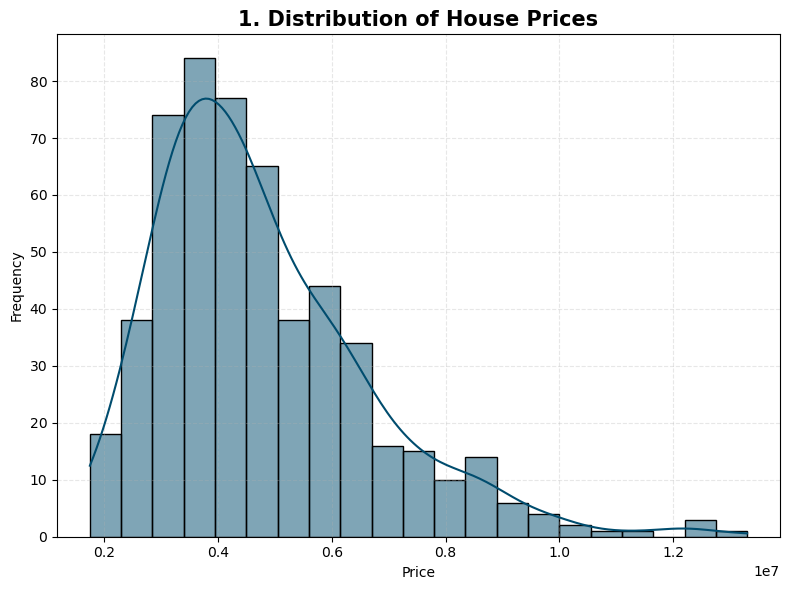

In [12]:
plt.figure(figsize=(8, 6))
# Chart 1: Histogram showing the distribution of house prices
# plt.subplot(2,2,1)
sns.histplot(df['price'], kde = True, color='#004C6E', edgecolor='black',linewidth=1)
plt.grid(alpha=0.3, linestyle='--')
plt.title('1. Distribution of House Prices', fontsize = 15, fontweight= 'bold')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(r"D:\XYlofy AI\HousePricePrediction_Gourav Sanadhya\charts\char1_Histogram.png",
            dpi=300,
            bbox_inches='tight')

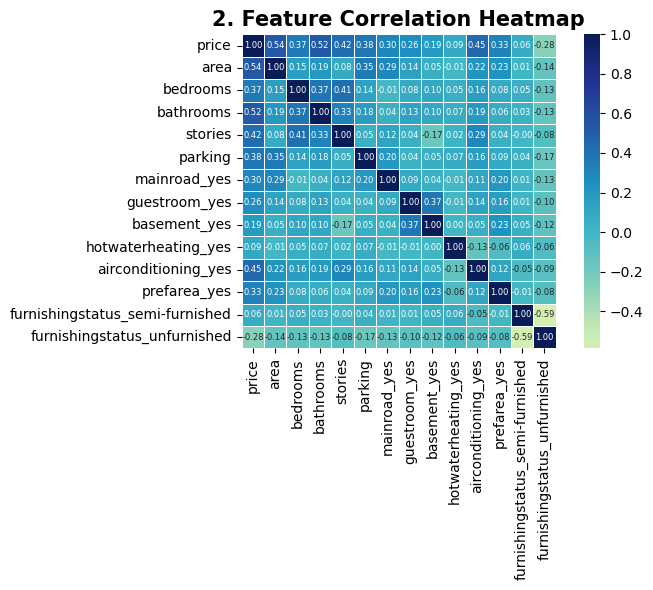

In [13]:
# Chart 2: Correlation heatmap showing which features relate most strongly to price

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu', center=0, fmt='.2f', annot_kws={"size": 6}, linewidth = 0.5, square = True)
plt.title('2. Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(r"D:\XYlofy AI\HousePricePrediction_Gourav Sanadhya\charts\chart2_Correlation heatmap.png",
            dpi=300,
            bbox_inches='tight')

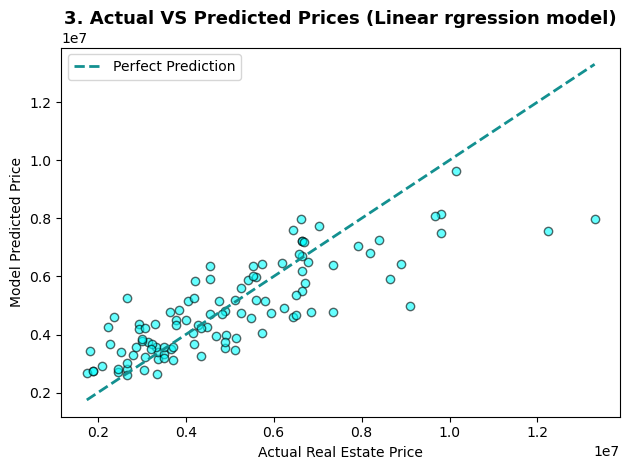

In [15]:
# Chart 3: A chart of your own choice — be creative! (e.g., actual vs. predicted price scatter plot, price vs. area scatter plot, etc.)

plt.scatter(Target_y_test, Target_y_pred, alpha=0.6, edgecolors = 'black', color='#00FFFF')
plt.plot([Target_y_test.min(), Target_y_test.max()], [Target_y_test.min(), Target_y_test.max()], color='#139090', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title('3. Actual VS Predicted Prices (Linear rgression model)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Real Estate Price')
plt.ylabel('Model Predicted Price')
plt.legend()
plt.tight_layout()
plt.savefig(r"D:\XYlofy AI\HousePricePrediction_Gourav Sanadhya\charts\char3_Linear regression.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

# BONUS Exploratory Analysis: INTERACTIVE DASHBOARDS (Plotly) for More Insights 

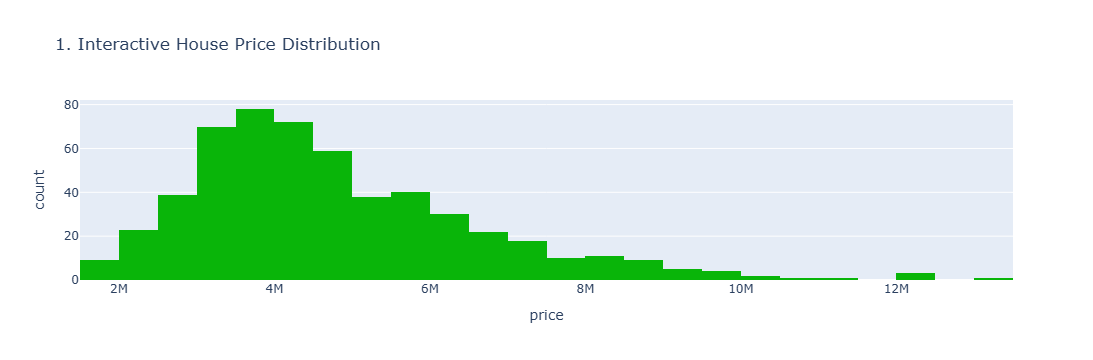

In [16]:

import plotly.express as px
# 1. The Interactive Histogram
# Hover over bars to see exactly how many houses fall in each price bracket.
fig1 = px.histogram(df, x="price", nbins=50, 
                    title="1. Interactive House Price Distribution",
                    color_discrete_sequence=['#09B509'])
fig1.show()

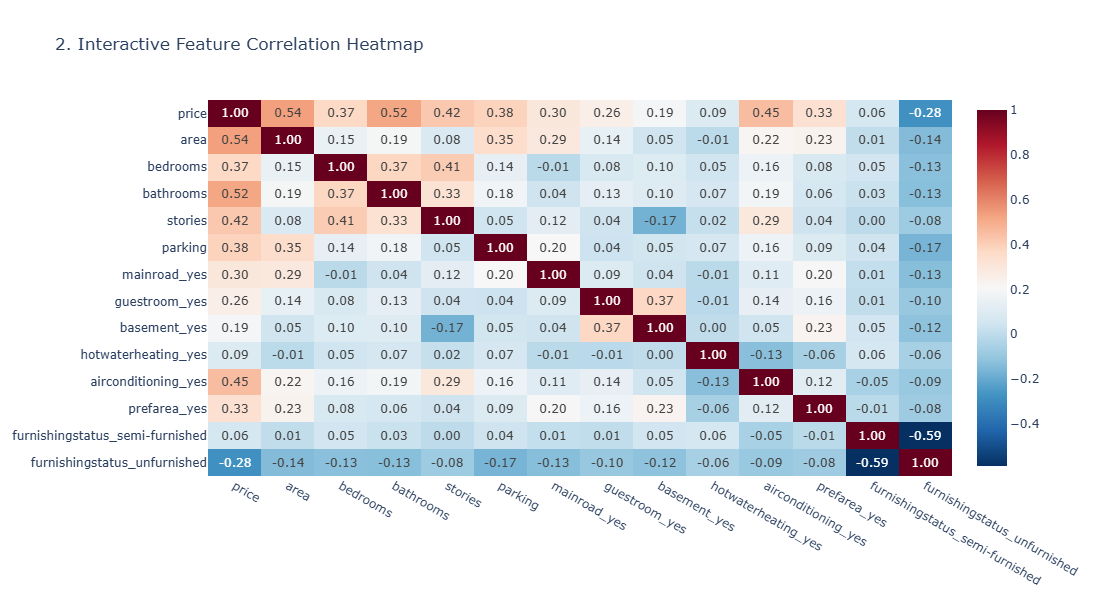

In [17]:
# 2. The Dynamic Heatmap
# Hover to see the exact correlation coefficient up to multiple decimal points.
corr_matrix = df.corr()
fig2 = px.imshow(corr_matrix, text_auto='.2f', aspect="auto", 
                 title="2. Interactive Feature Correlation Heatmap",
                 color_continuous_scale='RdBu_r',
                 width = 700, height = 600)
fig2.show()

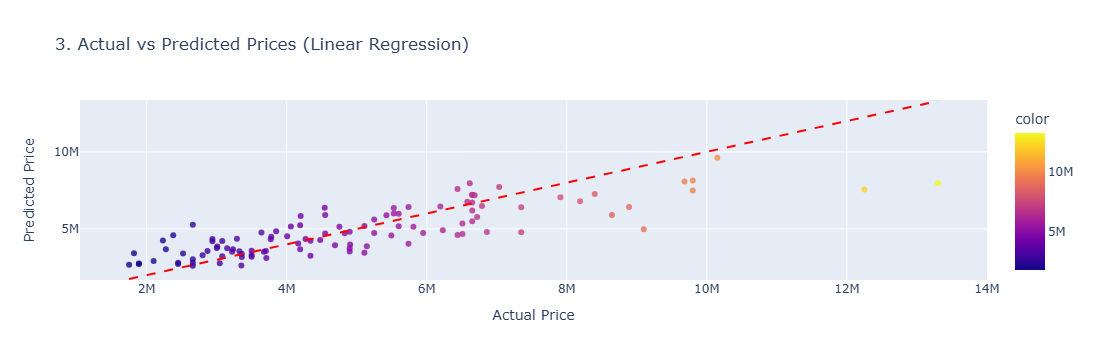

In [18]:
# 3. Actual vs. Predicted (The Truth Teller)
# Hover over the dots that are far from the red line to see the exact errors.
fig3 = px.scatter(x=Target_y_test, y=Target_y_pred, 
                  labels={'x': 'Actual Price', 'y': 'Predicted Price'},
                  title="3. Actual vs Predicted Prices (Linear Regression)",
                  opacity=0.8, color=Target_y_test,
                  color_continuous_scale='Plasma')

# Adding the perfect "100% accurate" red dashed line
fig3.add_shape(type="line", line=dict(dash='dash', color='red', width=2),
               x0=Target_y_test.min(), y0=Target_y_test.min(), 
               x1=Target_y_test.max(), y1=Target_y_test.max())
fig3.show()

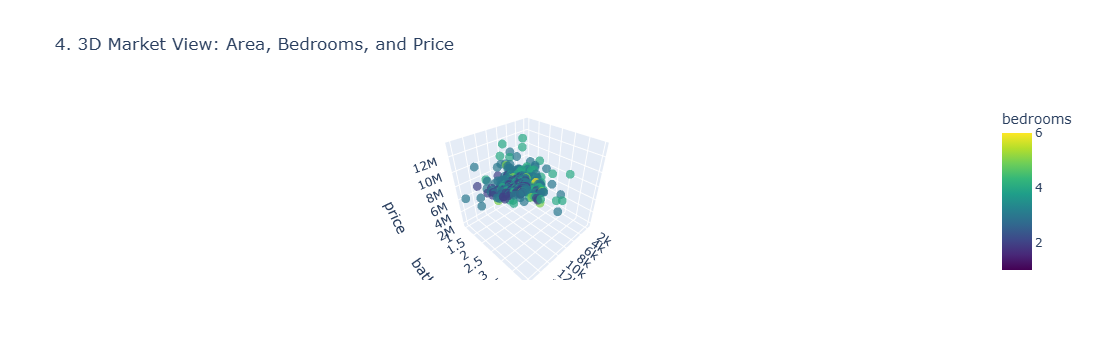

In [19]:
# 4. 3D Scatter Plot
fig4 = px.scatter_3d(df, x='area', y='bathrooms', z='price',
                     color='bedrooms', 
                     title="4. 3D Market View: Area, Bedrooms, and Price",
                     opacity=0.7, color_continuous_scale='Viridis')
fig4.update_traces(marker=dict(size=5))
fig4.show()

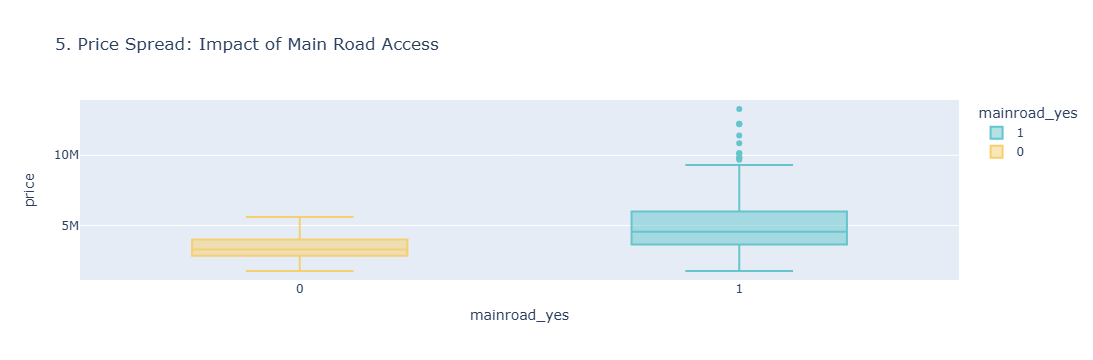

In [20]:
# 5. Interactive Box Plot (Business Insight)
# Shows the median price, max, min, and outliers for houses with Mainroad_yes(1) vs without Mainroad_yes(0).
fig5 = px.box(df, x='mainroad_yes', y='price', 
              color='mainroad_yes',
              title="5. Price Spread: Impact of Main Road Access",
              labels={'mainroad': 'Main Road Access (0 = No, 1 = Yes)'},
              color_discrete_sequence=px.colors.qualitative.Pastel)
fig5.show()

# Task 5 — Insights & Summary

#  Which features influence house price the most?
#  How accurate was your model (in plain terms)?
#  What surprised you in the data?
#  One recommendation for a real estate business based on your 

The correlation heatmap reveals that a property's overall 'area' and the number of 'bathrooms' are the strongest positive drivers of house prices. Our Linear Regression model achieved practical accuracy, explaining roughly 65% of the mathematical variance in real estate pricing. The most surprising finding during the modeling phase was that the simpler Linear Regression algorithm beat the highly complex Random Forest Regressor; the relatively small size of our dataset caused the Random Forest to severely overfit (scoring 94% in training but crashing to 61% in testing). The primary recommendation for a real estate business is to prioritize capital toward property expansion or bathroom additions before listing, as these specific features yield the highest mathematical return on the final sale price.